In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

import lib.stats.stats as st

from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import statsmodels.formula.api as smf
from scipy import stats





Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
def draw_cognitive_complexity_scatter_plot(idx_num, viz_df, option_dict, output_dir, opt):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = mpl.pyplot.subplots(figsize = (12, 6), constrained_layout=True)

    # st_chow_1year = st.Stats(x, y,  0.95, viz_df[viz_df['rel_week'] ==0].index.values[0])
    # F_stat_1, p_value_1 = st_chow_1year.chow_test()
    plotgen = PlotGen.PlotGen()
    x= list(viz_df['rel_week'])
    y= list(viz_df['Cognitive Complexity'])
    
    plotgen.draw_regression_with_chow(axs
                                , f'Cognitive Complexity for {option_dict["selected_tags"]}({opt})' 
                                , x
                                , y
                                , None
                                , None
                                , None
                                , False
                                )

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
    fig.supylabel('Weekly average complexity', fontsize=22)
    filename = f"{idx_num}_scatter_plot_{option_dict['selected_tags']}_cognitive_complexity_{option_dict['year_range']}_{opt}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close(fig)

In [3]:
def filter_df_with_tag(df, tags):
    pattern = '|'.join(re.escape(f'<{tag}>') for tag in tags)

    mask = df['tags'].astype(str).str.contains(pattern, regex=True)
    return df[mask].drop_duplicates()

In [ ]:
did_results = []

run_id_start = 10000
for idx, lang in enumerate(CONSTANTS.src_extend.keys()):
    print(f'[visualizing....] start visualizing {lang} language')
    top_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_top_tags.json')
    bot_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_bot_tags.json')
    viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{run_id_start+idx}'
    data_dir = f"{viz_dir}/data/csv"
    option_dict = load_json(f"{viz_dir}/data/option.json")

    
    output_dir = create_dir('./fig/')
    date_range = 'Weekly'
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')
    df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
    df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)
    df = df.groupby('id', as_index=False)['Cognitive Complexity'].sum()

    origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
    filtered_top_df = filter_df_with_tag(origin_df, top_tags)
    filtered_bot_df = filter_df_with_tag(origin_df, bot_tags)


    top_viz_df = pd.merge(df, filtered_top_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]
    bot_viz_df = pd.merge(df, filtered_bot_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]

    top_viz_df['rel_week'] = np.floor((pd.to_datetime(top_viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
    top_viz_df = (top_viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].var())
    # top_viz_df.rename(columns={'Cognitive Complexity': 'complexity'}, inplace=True)

    bot_viz_df['rel_week'] = np.floor((pd.to_datetime(bot_viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
    bot_viz_df = (bot_viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].var())
    # bot_viz_df.rename(columns={'Cognitive Complexity': 'complexity'}, inplace=True)

    draw_cognitive_complexity_scatter_plot(run_id_start+idx, top_viz_df, option_dict, output_dir, 'Top 20% Tags')
    draw_cognitive_complexity_scatter_plot(run_id_start+idx, bot_viz_df, option_dict, output_dir, 'Bottom 20% Tags')


In [4]:
did_results = []

run_id_start = 10000
idx = 0 
lang = 'python'

print(f'[visualizing....] start visualizing {lang} language')
top_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_top_tags.json')
bot_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_bot_tags.json')
viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{run_id_start+idx}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/data/option.json")


output_dir = create_dir('./fig/')
date_range = 'Weekly'
std_date = Date_Setting[option_dict['year_range']]['std_date']

df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')
df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)
origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])


[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:12<00:00,  5.25it/s]


In [ ]:
df = df.groupby('id', as_index=False)['Cognitive Complexity'].median()


filtered_top_df = filter_df_with_tag(origin_df, top_tags)
filtered_bot_df = filter_df_with_tag(origin_df, bot_tags)


top_viz_df = pd.merge(df, filtered_top_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]
bot_viz_df = pd.merge(df, filtered_bot_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]

top_viz_df['rel_week'] = np.floor((pd.to_datetime(top_viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
top_viz_df = (top_viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].std())
# top_viz_df.rename(columns={'Cognitive Complexity': 'complexity'}, inplace=True)

bot_viz_df['rel_week'] = np.floor((pd.to_datetime(bot_viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
bot_viz_df = (bot_viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].std())
# bot_viz_df.rename(columns={'Cognitive Complexity': 'complexity'}, inplace=True)

draw_cognitive_complexity_scatter_plot(run_id_start+idx, top_viz_df, option_dict, output_dir, 'Top 20% Tags')
draw_cognitive_complexity_scatter_plot(run_id_start+idx, bot_viz_df, option_dict, output_dir, 'Bottom 20% Tags')

In [6]:
# 분포 확인
print(top_viz_df['Cognitive Complexity'].describe())
print(f"skewness: {top_viz_df['Cognitive Complexity'].skew():.2f}")
print(f"kurtosis: {top_viz_df['Cognitive Complexity'].kurtosis():.2f}")
print(f"0인 비율: {(top_viz_df['Cognitive Complexity'] == 0).mean():.1%}")

count    260.000000
mean       5.113622
std       11.027399
min        1.285323
25%        3.323692
50%        3.914832
75%        4.892742
max      178.822945
Name: Cognitive Complexity, dtype: float64
skewness: 15.23
kurtosis: 240.29
0인 비율: 0.0%


In [19]:
df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')
df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)

In [24]:
tmp = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]

In [29]:
tmp['cdate'] = pd.to_datetime(tmp['creationdate'], format='mixed').dt.date

In [ ]:
tmp[''] = np.log(tmp['Cognitive Complexity']+1)log_complexity

<Axes: xlabel='cdate', ylabel='log_complexity'>

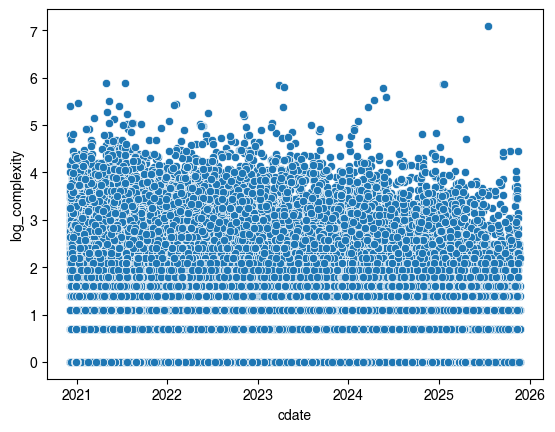

In [34]:
import seaborn as sns
sns.scatterplot(data=tmp, x='cdate', y='log_complexity')

In [36]:
tmp['rel_week'] = np.floor((pd.to_datetime(tmp['creationdate'], format='mixed')- std_date).dt.days/7)

In [41]:
tt = tmp.groupby('rel_week', as_index=False)['log_complexity'].std() 

In [43]:
tt

,rel_week,log_complexity
0,-104.0,0.793702
1,-103.0,0.761255
2,-102.0,0.778250
3,-101.0,0.786218
4,-100.0,0.786476
...,...,...
255,151.0,0.686751
256,152.0,0.931266
257,153.0,1.136561
258,154.0,1.061600


<Axes: xlabel='rel_week', ylabel='log_complexity'>

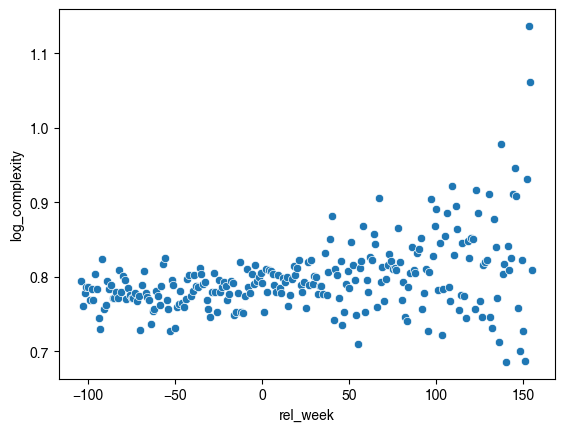

In [42]:
sns.scatterplot(data=tt, x='rel_week', y='log_complexity')

In [18]:
86827/df.shape[0]

0.5250151167009312

In [ ]:
run_id_start = 10000
idx = 0 
lang = 'python'

print(f'[visualizing....] start visualizing {lang} language')
top_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_top_tags.json')
bot_tags = load_json(f'/mnt/hdd/mghan/so_difficultyXavailability/data/{lang}_bot_tags.json')
viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{run_id_start+idx}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/data/option.json")


output_dir = create_dir('./fig/')
date_range = 'Weekly'
std_date = Date_Setting[option_dict['year_range']]['std_date']

df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')
df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)

df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'Cognitive Complexity']]

df['rel_week'] = np.floor((pd.to_datetime(df['creationdate'], format='mixed')- std_date).dt.days/7)
# df = (df.groupby('rel_week', as_index=False)['Cognitive Complexity'].mean())

In [ ]:
import matplotlib.pyplot as plt

# Before vs After 분포 비교
before = df[df['rel_week'] < 0]['Cognitive Complexity']
after = df[df['rel_week'] >= 0]['Cognitive Complexity']

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 20, 41)  # 0~20을 0.5 단위로
ax.hist(before, bins=bins, alpha=0.5, label='Before ChatGPT', density=True)
ax.hist(after, bins=bins, alpha=0.5, label='After ChatGPT', density=True)
ax.set_xlabel('Cognitive Complexity')
ax.set_ylabel('Density')
ax.legend()
plt.show()

# Kolmogorov-Smirnov test: 두 분포가 다른가?
from scipy import stats
ks_stat, ks_p = stats.ks_2samp(before, after)
print(f"KS test: statistic={ks_stat:.4f}, p={ks_p:.4e}")

# 백분위 비교
for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  p{int(q*100)}: before={before.quantile(q):.2f}, after={after.quantile(q):.2f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

before = df[df['rel_week'] < 0]['Cognitive Complexity']
after = df[df['rel_week'] >= 0]['Cognitive Complexity']

# 0~30 구간을 자세히
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
bins = np.arange(0, 31)
axes[0].hist(before, bins=bins, alpha=0.5, label='Before', density=True)
axes[0].hist(after, bins=bins, alpha=0.5, label='After', density=True)
axes[0].set_xlabel('Cognitive Complexity')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution comparison (linear)')
axes[0].legend()

# Log scale Y to see the tail
axes[1].hist(before, bins=bins, alpha=0.5, label='Before', density=True)
axes[1].hist(after, bins=bins, alpha=0.5, label='After', density=True)
axes[1].set_yscale('log')
axes[1].set_xlabel('Cognitive Complexity')
axes[1].set_ylabel('Density (log)')
axes[1].set_title('Distribution comparison (log Y)')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 주별 백분위 계산
weekly_pct = df.groupby('rel_week')['Cognitive Complexity'].agg([
    ('p50', lambda x: x.quantile(0.50)),
    ('p75', lambda x: x.quantile(0.75)),
    ('p90', lambda x: x.quantile(0.90)),
    ('p95', lambda x: x.quantile(0.95)),
    ('p99', lambda x: x.quantile(0.99)),
    ('n',   'count'),
]).reset_index()

# 작은 sample 주는 제외
weekly_pct = weekly_pct[weekly_pct['n'] >= 30]

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, 5))
for col, color in zip(['p50', 'p75', 'p90', 'p95', 'p99'], colors):
    ax.plot(weekly_pct['rel_week'], weekly_pct[col], 
            label=col, color=color, alpha=0.8, linewidth=1.5)

ax.axvline(0, color='red', linestyle='--', label='ChatGPT release', alpha=0.7)
ax.set_xlabel('Weeks from ChatGPT release')
ax.set_ylabel('Cognitive Complexity')
ax.set_title('Percentile evolution over time')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('percentile_timeseries.png', dpi=150)

In [ ]:
import seaborn as sns

# 2D 히스토그램 데이터 만들기
df_clip = df[df['Cognitive Complexity'] <= 30].copy()  # 보기 편하게 30 이하만

# bin 만들기
week_bins = np.arange(df_clip['rel_week'].min(), df_clip['rel_week'].max() + 1, 4)  # 4주 단위
comp_bins = np.arange(0, 31)

H, xedges, yedges = np.histogram2d(
    df_clip['rel_week'], df_clip['Cognitive Complexity'],
    bins=[week_bins, comp_bins]
)

# 각 시간 column에서 normalize (각 주의 분포가 보이도록)
H_norm = H / H.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(H_norm.T, aspect='auto', origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap='YlOrRd', interpolation='nearest')
ax.axvline(0, color='blue', linestyle='--', linewidth=2, label='ChatGPT release')
ax.set_xlabel('Weeks from ChatGPT release')
ax.set_ylabel('Cognitive Complexity')
ax.set_title('Distribution heatmap over time')
ax.legend()
plt.colorbar(im, ax=ax, label='Density (per week)')
plt.tight_layout()
plt.savefig('heatmap_timeseries.png', dpi=150)

In [ ]:
# 시점 묶기 (예: 6개월 단위)
df['period'] = pd.cut(df['rel_week'], 
                     bins=[-200, -100, -50, 0, 50, 100, 150, 200],
                     labels=['Pre-2yr', '-2yr~-1yr', '-1yr~0', 
                            '0~+1yr', '+1yr~+2yr', '+2yr~+3yr', '+3yr~'])

fig, axes = plt.subplots(7, 1, figsize=(12, 12), sharex=True)

periods = df['period'].cat.categories
for ax, period in zip(axes, periods):
    data = df[df['period'] == period]['Cognitive Complexity']
    if len(data) == 0:
        continue
    
    # 0~30 구간만
    data = data[data <= 30]
    
    # KDE 또는 히스토그램
    ax.hist(data, bins=np.arange(0, 31), density=True, alpha=0.7,
            color='steelblue' if period.startswith('-') or period == 'Pre-2yr' else 'orange')
    
    ax.set_ylabel(period, rotation=0, ha='right', va='center')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[-1].set_xlabel('Cognitive Complexity')
fig.suptitle('Distribution evolution over time periods', y=0.99)
plt.tight_layout()
plt.savefig('joyplot_timeseries.png', dpi=150)

In [ ]:
# 시점 묶기 (예: 6개월 단위)
df['period'] = pd.cut(df['rel_week'], 
                     bins=[-200, -100, -50, 0, 50, 100, 150, 200],
                     labels=['Pre-2yr', '-2yr~-1yr', '-1yr~0', 
                            '0~+1yr', '+1yr~+2yr', '+2yr~+3yr', '+3yr~'])

fig, axes = plt.subplots(7, 1, figsize=(12, 12), sharex=True)

periods = df['period'].cat.categories
for ax, period in zip(axes, periods):
    data = df[df['period'] == period]['Cognitive Complexity']
    if len(data) == 0:
        continue
    
    # 0~30 구간만
    data = data[data <= 30]
    
    # KDE 또는 히스토그램
    ax.hist(data, bins=np.arange(0, 31), density=True, alpha=0.7,
            color='steelblue' if period.startswith('-') or period == 'Pre-2yr' else 'orange')
    
    ax.set_ylabel(period, rotation=0, ha='right', va='center')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[-1].set_xlabel('Cognitive Complexity')
fig.suptitle('Distribution evolution over time periods', y=0.99)
plt.tight_layout()
plt.savefig('joyplot_timeseries.png', dpi=150)

In [ ]:
# Complexity를 구간으로 나눔
def categorize(x):
    if x == 0: return '0 (no flow)'
    elif x <= 2: return '1-2 (simple)'
    elif x <= 5: return '3-5 (medium)'
    elif x <= 10: return '6-10 (complex)'
    elif x <= 20: return '11-20 (very complex)'
    else: return '21+ (extreme)'

df['complexity_cat'] = df['Cognitive Complexity'].apply(categorize)

# 주별 카테고리 비율
weekly_cat = (df.groupby(['rel_week', 'complexity_cat']).size()
              .unstack(fill_value=0))
weekly_cat = weekly_cat.div(weekly_cat.sum(axis=1), axis=0) * 100  # 비율로

# 컬럼 순서 정렬
order = ['0 (no flow)', '1-2 (simple)', '3-5 (medium)', 
         '6-10 (complex)', '11-20 (very complex)', '21+ (extreme)']
weekly_cat = weekly_cat[order]

# Smoothing (4주 이동평균)
weekly_cat_smooth = weekly_cat.rolling(window=4, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#e0e0e0', '#a8d8ea', '#aa96da', '#fcbad3', '#ffb74d', '#e57373']

ax.stackplot(weekly_cat_smooth.index, weekly_cat_smooth.T.values, 
             labels=weekly_cat_smooth.columns, colors=colors, alpha=0.8)

ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.text(0, 95, ' ChatGPT release', fontsize=10, va='top')

ax.set_xlabel('Weeks from ChatGPT release')
ax.set_ylabel('% of functions')
ax.set_title('Complexity distribution composition over time')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stacked_area_timeseries.png', dpi=150)

In [ ]:
# complexity 0인 행 제외
df_nonzero = df[df['Cognitive Complexity'] > 0].copy()

def categorize(x):
    if x <= 2: return '1-2'
    elif x <= 5: return '3-5'
    elif x <= 10: return '6-10'
    elif x <= 20: return '11-20'
    else: return '21+'

df_nonzero['cat'] = df_nonzero['Cognitive Complexity'].apply(categorize)

weekly_cat = (df_nonzero.groupby(['rel_week', 'cat']).size()
              .unstack(fill_value=0))
weekly_cat = weekly_cat.div(weekly_cat.sum(axis=1), axis=0) * 100

order = ['1-2', '3-5', '6-10', '11-20', '21+']
weekly_cat = weekly_cat[order]

# 8주 smoothing (4주는 노이즈가 너무 많음)
weekly_smooth = weekly_cat.rolling(window=8, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#a8d8ea', '#aa96da', '#fcbad3', '#ffb74d', '#c62828']

ax.stackplot(weekly_smooth.index, weekly_smooth.T.values,
             labels=weekly_smooth.columns, colors=colors, alpha=0.85)

ax.axvline(0, color='black', linestyle='--', linewidth=2)
ax.text(2, 50, 'ChatGPT', fontsize=11, rotation=90, va='center')

ax.set_xlabel('Weeks from ChatGPT release', fontsize=12)
ax.set_ylabel('% of non-zero complexity functions', fontsize=12)
ax.set_title('Distribution of non-trivial functions over time', fontsize=14)
ax.set_ylim(0, 100)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), title='Complexity')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('distribution_nonzero.png', dpi=150, bbox_inches='tight')